In [45]:
!pip install spectral tqdm scikit-learn

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [46]:
import os
import numpy as np
import tensorflow as tf
from scipy.io import loadmat
from tqdm import tqdm
import matplotlib.pyplot as plt
import spectral

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import minmax_scale
from sklearn.metrics import accuracy_score, confusion_matrix, cohen_kappa_score

from tensorflow.keras.layers import (
    Input, Conv3D, Conv2D, Dense, Dropout, Reshape,
    Concatenate, Add, Multiply,
    GlobalAveragePooling2D,
    Permute
)

from tensorflow.keras.models import Model

In [47]:
from tensorflow.keras import mixed_precision

mixed_precision.set_global_policy('mixed_float16')

print("Policy:", mixed_precision.global_policy())

Policy: <DTypePolicy "mixed_float16">


In [48]:
def loadData(name):

    data_path = '/content/drive/MyDrive/datasets'

    if name == 'Tangdaowan':
        data = loadmat(os.path.join(data_path, 'QUH-Tangdaowan.mat'))['Tangdaowan']
        labels = loadmat(os.path.join(data_path, 'QUH-Tangdaowan_GT.mat'))['TangdaowanGT']
        class_name = [
            "Rubber track","Flaggingv","Sandy","Asphalt","Boardwalk",
            "Rocky shallows","Grassland","Bulrush","Gravel road",
            "Ligustrum vicaryi","Coniferous pine","Spiraea","Bare soil",
            "Buxus sinica","Photinia serrulata","Populus",
            "Ulmus pumila L","Seawater"
        ]

    elif name == 'Qingyun':
        data = loadmat(os.path.join(data_path, 'QUH-Qingyun.mat'))['Chengqu']
        labels = loadmat(os.path.join(data_path, 'QUH-Qingyun_GT.mat'))['ChengquGT']
        class_name = [
            "Trees","Concrete building","Car",
            "Ironhide building","Plastic playground","Asphalt road"
        ]

    elif name == 'Pingan':
        data = loadmat(os.path.join(data_path, 'QUH-Pingan.mat'))['Haigang']
        labels = loadmat(os.path.join(data_path, 'QUH-Pingan_GT.mat'))['HaigangGT']
        class_name = [
            "Ship","Seawater","Trees","Concrete structure building",
            "Floating pier","Asphalt road","Brick houses",
            "Steel houses","Wharf construction land","Car","Road"
        ]

    return data, labels, class_name

In [87]:
def applyPCA(X, numComponents=15, normalization=True):

    H, W, C = X.shape
    numComponents = min(numComponents, C)

    newX = np.reshape(X, (-1, C))

    pca = PCA(n_components=numComponents)
    newX = pca.fit_transform(newX)

    if normalization:
        newX = minmax_scale(newX, axis=1)

    newX = np.reshape(newX, (H, W, numComponents))

    return newX

In [88]:
def get_img_indexes(class_map, removeZeroindexes=True):

    if removeZeroindexes:
        indices = np.argwhere(class_map != 0)
    else:
        indices = np.argwhere(class_map != None)

    labels = class_map[indices[:,0], indices[:,1]]

    indices = [tuple(i) for i in indices]

    return indices, np.array(labels.tolist()) - 1

In [89]:
def splitTrainTestSet(X, y, testRatio):

    return train_test_split(
        X,
        y,
        test_size=testRatio,
        stratify=y,
        random_state=42
    )

In [90]:
def createImageCubes(X, indices, windowSize):

    margin = windowSize // 2

    N,M,P = X.shape

    X_padded = np.zeros((N+2*margin, M+2*margin, P))

    X_padded[margin:N+margin, margin:M+margin,:] = X

    patches=[]

    for idx in indices:

        i,j = idx

        i+=margin
        j+=margin

        patch = X_padded[i-margin:i+margin+1, j-margin:j+margin+1,:]

        patches.append(patch)

    patches=np.array(patches)

    patches = patches[...,np.newaxis]

    return patches

In [91]:
def spectral_mixer_block(x, hidden_dim, num_blocks=2):

    H,W,C,D = x.shape[1:]

    x = Permute((1,2,4,3))(x)

    x = Reshape((H*W, D, C))(x)

    for _ in range(num_blocks):

        x1 = Dense(hidden_dim, activation='gelu')(x)

        x1 = Dense(C)(x1)

        x = Add()([x,x1])

    return Reshape((H,W,C,D))(x)

In [92]:
def spatial_mixer_block(x, hidden_dim, num_blocks=2):

    H,W,C,D = x.shape[1:]

    x = Permute((3,4,1,2))(x)

    x = Reshape((C,D,H*W))(x)

    for _ in range(num_blocks):

        x1 = Dense(hidden_dim, activation='gelu')(x)

        x1 = Dense(H*W)(x1)

        x = Add()([x,x1])

    x = Permute((3,1,2))(x)

    return Reshape((H,W,C,D))(x)

In [105]:
from tensorflow.keras.layers import Lambda, Concatenate, Conv2D, Multiply


def gc_block(x, reduction=16):

    channels = x.shape[-1]

    # Context Modeling
    context = Conv2D(1, 1)(x)
    context = Lambda(lambda z: tf.nn.softmax(z, axis=1))(context)

    context = Multiply()([x, context])

    # FIX for KerasTensor
    context = Lambda(lambda z: tf.reduce_sum(z, axis=[1,2], keepdims=True))(context)

    # Transform
    transform = Conv2D(channels//reduction, 1, activation='gelu')(context)
    transform = Conv2D(channels, 1, activation='sigmoid')(transform)

    # Fusion
    out = Multiply()([x, transform])

    return out

In [102]:
def SS_MixNet(input_shape, num_classes, mixer_dim=256):

    inp = Input(shape=input_shape)

    x = Conv3D(32,(3,3,3),padding='same',activation='gelu')(inp)
    x = Conv3D(64,(3,3,3),padding='same',activation='gelu')(x)

    x_spe = spectral_mixer_block(x, mixer_dim)
    x_spa = spatial_mixer_block(x, mixer_dim)

    x = Concatenate(axis=4)([x_spe,x_spa])

    H,W,C,F = x.shape[1:]

    x = Reshape((H,W,C*F))(x)

    x = gc_block(x)

    res = Conv2D(x.shape[-1],1,padding='same',activation='gelu')(x)

    x = Add()([x,res])

    x = GlobalAveragePooling2D()(x)

    x = Dropout(0.4)(x)

    out = Dense(num_classes,activation='softmax',dtype='float32')(x)

    model = Model(inp,out)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
        metrics=['accuracy']
    )

    return model

In [103]:
DATASET='Tangdaowan'

data, gt, class_name = loadData(DATASET)

print(data.shape)

(1740, 860, 176)


In [123]:
data = applyPCA(data, numComponents=15)

In [97]:
indexes, labels = get_img_indexes(gt)

X_train_idx, X_test_idx, y_train, y_test = splitTrainTestSet(indexes,labels,0.95)

X_train_idx, X_val_idx, y_train, y_val = splitTrainTestSet(X_train_idx,y_train,0.30)

In [98]:
window_size=13

X_train = createImageCubes(data,X_train_idx,window_size)
X_val = createImageCubes(data,X_val_idx,window_size)

y_train = tf.keras.utils.to_categorical(y_train)
y_val = tf.keras.utils.to_categorical(y_val)

In [108]:
model = SS_MixNet(
    X_train.shape[1:],
    num_classes=len(class_name),
    mixer_dim=256
)
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 13, 13,    │          0 │ -                 │
│ (InputLayer)        │ 15, 1)            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_12 (Conv3D)  │ (None, 13, 13,    │        896 │ input_layer_6[0]… │
│                     │ 15, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_13 (Conv3D)  │ (None, 13, 13,    │     55,360 │ conv3d_12[0][0]   │
│                     │ 15, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ permute_19          │ (None, 15, 64,    │          0 │ conv3d_13[0][0]   │
│ (Permute)           │ 13, 13)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ permute_18          │ (None, 13, 13,    │          0 │ conv3d_13[0][0]   │
│ (Permute)           │ 64, 15)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_32          │ (None, 15, 64,    │          0 │ permute_19[0][0]  │
│ (Reshape)           │ 169)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_30          │ (None, 169, 64,   │          0 │ permute_18[0][0]  │
│ (Reshape)           │ 15)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_55 (Dense)    │ (None, 15, 64,    │     43,520 │ reshape_32[0][0]  │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_51 (Dense)    │ (None, 169, 64,   │      4,096 │ reshape_30[0][0]  │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_56 (Dense)    │ (None, 15, 64,    │     43,433 │ dense_55[0][0]    │
│                     │ 169)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_52 (Dense)    │ (None, 169, 64,   │      3,855 │ dense_51[0][0]    │
│                     │ 15)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_29 (Add)        │ (None, 15, 64,    │          0 │ reshape_32[0][0], │
│                     │ 169)              │            │ dense_56[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_27 (Add)        │ (None, 169, 64,   │          0 │ reshape_30[0][0], │
│                     │ 15)               │            │ dense_52[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_57 (Dense)    │ (None, 15, 64,    │     43,520 │ add_29[0][0]      │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_53 (Dense)    │ (None, 169, 64,   │      4,096 │ add_27[0][0]      │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_58 (Dense)    │ (None, 15, 64,    │     43,433 │ dense_57[0][0]    │
│                     │ 169)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_54 (Dense)    │ (None, 169, 64,   │      3,855 │ dense_53[0][0]  

 Total params: 4,433,723 (16.91 MB)

 Trainable params: 4,433,723 (16.91 MB)

 Non-trainable params: 0 (0.00 B)

In [110]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    f"{DATASET}_SS_MixNet_GC.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=8,
    min_lr=5e-5
)

history = model.fit(
    X_train,
    y_train,
    epochs=80,
    batch_size=256,
    validation_data=(X_val,y_val),
    callbacks=[checkpoint, lr_callback]
)

Epoch 1/80
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 725ms/step - accuracy: 0.4418 - loss: 2.0370
Epoch 1: val_accuracy improved from None to 0.76905, saving model to Tangdaowan_SS_MixNet_GC.keras

Epoch 1: finished saving model to Tangdaowan_SS_MixNet_GC.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.5718 - loss: 1.5898 - val_accuracy: 0.7690 - val_loss: 0.9934 - learning_rate: 3.0000e-04
Epoch 2/80
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step - accuracy: 0.7815 - loss: 0.9214
Epoch 2: val_accuracy improved from 0.76905 to 0.85349, saving model to Tangdaowan_SS_MixNet_GC.keras

Epoch 2: finished saving model to Tangdaowan_SS_MixNet_GC.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 40s 515ms/step - accuracy: 0.8047 - loss: 0.8655 - val_accuracy: 0.8535 - val_loss: 0.7388 - learning_rate: 3.0000e-04
Epoch 3/80
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step - accuracy: 0.8444 - loss: 0.7518
Epoch 3: val_accuracy improved from 0.85349 to 0.85851, saving model to Tangdaowan_SS_MixNet_GC.keras

Epoch 3: finished s

In [111]:
import pickle

with open("training_history.pkl", "wb") as f:
    pickle.dump(history.history, f)

print("Training history saved.")

Training history saved.


In [112]:
from google.colab import files

files.download("training_history.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [113]:
import numpy as np

np.save("training_history.npy", history.history)

print("Training history saved as training_history.npy")

Training history saved as training_history.npy


In [114]:
from google.colab import files
files.download("training_history.npy")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [115]:
import seaborn as sns

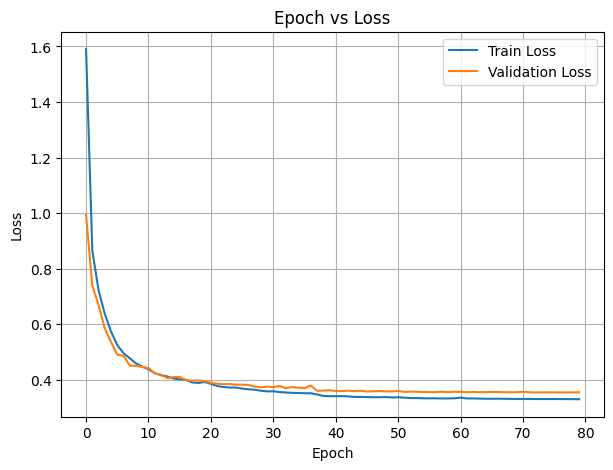

In [116]:
plt.figure(figsize=(7,5))

plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")

plt.title("Epoch vs Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()


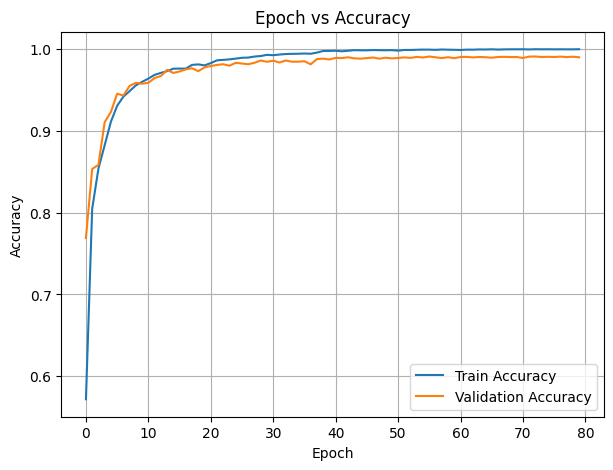

In [117]:
plt.figure(figsize=(7,5))

plt.plot(history.history['accuracy'], label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")

plt.title("Epoch vs Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)

plt.show()

In [121]:
def predict_by_batching(model, idx, batch_size, X, windowSize):

    preds=[]

    for i in tqdm(range(0,len(idx),batch_size)):

        batch = createImageCubes(X,idx[i:i+batch_size],windowSize)
        batch = np.expand_dims(batch, axis=-1)

        preds.append(model.predict(batch,verbose=0))

    return np.concatenate(preds)

100%|██████████| 265/265 [06:57<00:00,  1.57s/it]


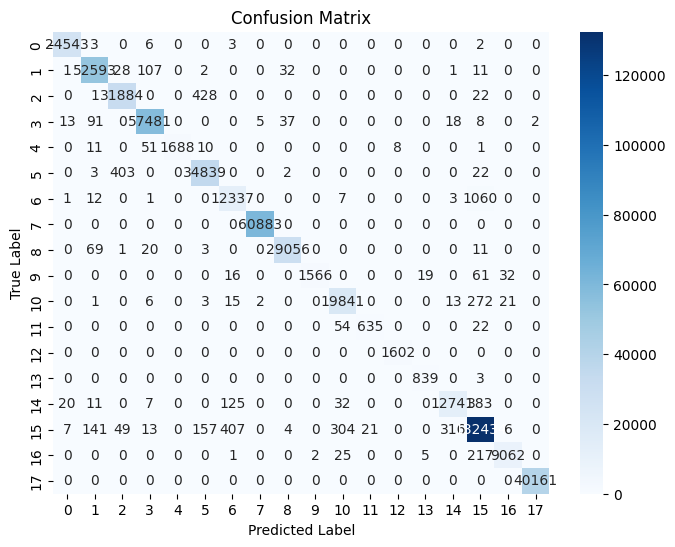

Overall Accuracy: 99.0
Average Accuracy: 97.52
Kappa: 98.86


In [124]:
Y_pred_test = predict_by_batching(model,X_test_idx,2000,data,window_size)

y_pred_test = np.argmax(Y_pred_test,axis=1)

oa = accuracy_score(y_test,y_pred_test)
kappa = cohen_kappa_score(y_test,y_pred_test)

cm = confusion_matrix(y_test,y_pred_test)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

class_acc = cm.diagonal()/cm.sum(axis=1)
aa = np.mean(class_acc)

print("Overall Accuracy:",round(oa*100,2))
print("Average Accuracy:",round(aa*100,2))
print("Kappa:",round(kappa*100,2))

In [125]:
import json

test_metrics = {
    "Overall Accuracy (OA)": float(oa),
    "Average Accuracy (AA)": float(aa),
    "Kappa Score": float(kappa)
}

with open("test_metrics.json", "w") as f:
    json.dump(test_metrics, f, indent=4)

print("Test metrics saved.")

Test metrics saved.


In [126]:
from google.colab import files

files.download("test_metrics.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd

cm_df = pd.DataFrame(cm, index=class_name, columns=class_name)

cm_df.to_csv("confusion_matrix_test.csv")

print("Confusion matrix saved.")

Confusion matrix saved.


In [127]:
from google.colab import files

files.download("confusion_matrix_test.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [128]:
from sklearn.metrics import classification_report

In [129]:
print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_test,
        target_names=class_name,
        digits=4
    )
)


Classification Report:

                    precision    recall  f1-score   support

      Rubber track     0.9983    0.9994    0.9989     24557
         Flaggingv     0.9935    0.9966    0.9950     52775
             Sandy     0.9851    0.9861    0.9856     32335
           Asphalt     0.9963    0.9970    0.9967     57655
         Boardwalk     1.0000    0.9542    0.9766      1769
    Rocky shallows     0.9830    0.9878    0.9854     35269
         Grassland     0.9561    0.9192    0.9373     13421
           Bulrush     0.9999    1.0000    0.9999     60883
       Gravel road     0.9974    0.9964    0.9969     29160
 Ligustrum vicaryi     0.9987    0.9244    0.9601      1694
   Coniferous pine     0.9792    0.9835    0.9813     20174
           Spiraea     0.9680    0.8931    0.9290       711
         Bare soil     0.9950    1.0000    0.9975      1602
      Buxus sinica     0.9722    0.9964    0.9842       842
Photinia serrulata     0.9732    0.9566    0.9648     13319
           Pop

In [130]:
import pandas as pd

report = classification_report(
    y_test,
    y_pred_test,
    target_names=class_name,
    output_dict=True
)

df_report = pd.DataFrame(report).transpose()

df_report.to_csv("classification_report.csv")

pd.DataFrame(cm).to_csv("confusion_matrix.csv")

print("Results saved.")

Results saved.


In [131]:
import pandas as pd

report_df = pd.DataFrame(report).transpose()

report_df.to_csv("classification_report.csv")

print("Classification report saved.")

Classification report saved.


In [132]:
from google.colab import files

files.download("classification_report.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [133]:
import pandas as pd
import numpy as np

# -----------------------------
# Compute per-class accuracy
# -----------------------------
class_accuracy = cm.diagonal() / cm.sum(axis=1) * 100

rows = []

for i in range(len(class_name)):

    train_count = (y_train.argmax(axis=1) == i).sum()
    val_count   = (y_val.argmax(axis=1) == i).sum()
    test_count  = (y_test == i).sum()
    total_count = (gt == (i+1)).sum()

    rows.append([
        class_name[i],
        train_count,
        val_count,
        test_count,
        total_count,
        round(class_accuracy[i], 2)
    ])

# -----------------------------
# Create DataFrame
# -----------------------------
df = pd.DataFrame(
    rows,
    columns=[
        "Class",
        "Train",
        "Val",
        "Test",
        "Total",
        "SS-MixNet (%)"
    ]
)

# -----------------------------
# Summary Metrics
# -----------------------------
summary_rows = pd.DataFrame([
    ["OA (%)", "", "", "", "", round(oa * 100, 2)],
    ["AA (%)", "", "", "", "", round(aa * 100, 2)],
    ["Kappa (×100)", "", "", "", "", round(kappa * 100, 2)]
], columns=df.columns)

df_final = pd.concat([df, summary_rows], ignore_index=True)

# -----------------------------
# Pretty Print Table
# -----------------------------
print("\n")
print("=" * 90)
print(f"{'Classification Performance of SS-MixNet on ' + DATASET:^90}")
print("=" * 90)

print(f"{'Class':<25}{'Train':>8}{'Val':>8}{'Test':>10}{'Total':>10}{'Accuracy (%)':>15}")
print("-" * 90)

for i in range(len(class_name)):
    print(f"{df.iloc[i,0]:<25}"
          f"{df.iloc[i,1]:>8}"
          f"{df.iloc[i,2]:>8}"
          f"{df.iloc[i,3]:>10}"
          f"{df.iloc[i,4]:>10}"
          f"{df.iloc[i,5]:>15}")

print("-" * 90)

print(f"{'Overall Accuracy (OA)':<25}{'':>8}{'':>8}{'':>10}{'':>10}{round(oa*100,2):>15}")
print(f"{'Average Accuracy (AA)':<25}{'':>8}{'':>8}{'':>10}{'':>10}{round(aa*100,2):>15}")
print(f"{'Kappa (×100)':<25}{'':>8}{'':>8}{'':>10}{'':>10}{round(kappa*100,2):>15}")

print("=" * 90)




                  Classification Performance of SS-MixNet on Tangdaowan                   
Class                       Train     Val      Test     Total   Accuracy (%)
------------------------------------------------------------------------------------------
Rubber track                  904     388     24557     25849          99.94
Flaggingv                    1945     833     52775     55553          99.66
Sandy                        1191     511     32335     34037          98.61
Asphalt                      2124     911     57655     60690           99.7
Boardwalk                      65      28      1769      1862          95.42
Rocky shallows               1299     557     35269     37125          98.78
Grassland                     494     212     13421     14127          91.92
Bulrush                      2243     961     60883     64087          100.0
Gravel road                  1075     460     29160     30695          99.64
Ligustrum vicaryi              62      27     

In [137]:
def get_class_map(model, X, label, window_size):

    indexes = np.argwhere(label != None)

    indexes = [tuple(i) for i in indexes]

    preds = []

    for i in tqdm(range(0, len(indexes), 2000)):
        batch_idx = indexes[i:i+2000]

        patches = createImageCubes(X, batch_idx, window_size)

        y_pred = model.predict(patches, verbose=0)

        preds.append(y_pred)

    preds = np.concatenate(preds)

    preds = np.argmax(preds, axis=1)

    Predicted_Class_Map = np.reshape(preds, label.shape)

    return Predicted_Class_Map

In [138]:
def img_display(data=None, rgb_band=None, classes=None, title=None, figsize=(7,7)):

    if data is not None:
        im_rgb = data[:,:,rgb_band]
        im_rgb = im_rgb / np.max(im_rgb) * 255
        im_rgb = np.asarray(im_rgb, np.uint8)

        plt.figure(figsize=figsize)
        plt.imshow(im_rgb)
        plt.title(title)
        plt.axis('off')
        plt.show()

    elif classes is not None:

        unique_classes = np.unique(classes)

        rgb_class = np.zeros((classes.shape[0], classes.shape[1], 3))

        colors = spectral.spy_colors

        for i in unique_classes:
            rgb_class[classes == i] = colors[i]

        rgb_class = np.asarray(rgb_class, np.uint8)

        plt.figure(figsize=figsize)
        plt.imshow(rgb_class)
        plt.title(title)
        plt.axis('off')
        plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 4 variables whereas the saved optimizer has 66 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 62 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
100%|██████████| 749/749 [20:13<00:00,  1.62s/it]


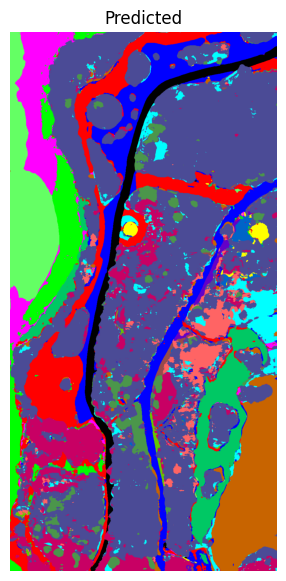

In [141]:
model = SS_MixNet(
    X_train.shape[1:],
    num_classes=len(class_name)
)

model.build((None, *X_train.shape[1:]))

# Load weights
model.load_weights(f"{DATASET}_SS_MixNet_GC.keras")

# Predict map
Predicted_Class_Map = get_class_map(model, data, gt, window_size)

img_display(classes=Predicted_Class_Map, title='Predicted')

In [142]:
model.save("SS_MixNet_GC.keras")

from google.colab import files
files.download("SS_MixNet_GC.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [143]:
model.save_weights("SS_MixNet_GC_T4.weights.h5")

from google.colab import files
files.download("SS_MixNet_GC_T4.weights.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [144]:
import numpy as np

np.save("X_test_idx.npy", X_test_idx)
np.save("y_test.npy", y_test)

from google.colab import files
files.download("X_test_idx.npy")
files.download("y_test.npy")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>